In [1]:
import pandas as pd
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()
db_url = os.getenv("DATABASE_URL")
engine = create_engine(db_url)

# Шаг.1 Комплексный аудит аномальных транзакций в январе 2026 года
Описание шага:

Цель этапа — провести точечный аудит сырых данных за январь 2026 года для установления природы аномального всплеска удержания на графиках. Нам необходимо определить структуру этого пика: является ли он следствием технического сбоя или результатом реального массового наплыва покупателей.

Дополнительно проводится анализ поведения лояльных клиентов, совершивших повторные (дублирующие) транзакции в течение одного месяца, чтобы оценить их суммарный вклад в январскую выручку.

In [2]:
# Выгружаем сырые данные за аномальный январь 2026 года
january_2026_query = """
select
	client_uuid,
	trans_date::date as trans_date,
	nullif(amount,'error'):: numeric as amount,
	product_list,
	promo_code,
	channel
from public.raw_transactions
where EXTRACT(year from (trans_date::date)) = 2026
	and EXTRACT(month from (trans_date::date)) = 1
"""
df_january = pd.read_sql(january_2026_query, engine,parse_dates=['trans_date'])
df_january.head(3)

,client_uuid,trans_date,amount,product_list,promo_code,channel
0,56ae8306-1ad6-4662-90a9-9517c17dddbe,2026-01-08,14943.61,"Shorts,Jacket,Sneakers",agency,online
1,5286eafe-a53b-46e2-bb92-c453b71bb60d,2026-01-09,5942.10,Hat,NaN,online
2,d4c95140-e094-4a48-9dcf-e8b0825e2a1e,2026-01-30,7006.79,"Jacket,Tshirt,Shorts",others,NaN


In [3]:
df_january.describe()

,trans_date,amount
count,789,766.000000
mean,2026-01-16 06:52:28,7214.042650
min,2026-01-01 00:00:00,-475.220000
25%,2026-01-09 00:00:00,3288.715000
50%,2026-01-17 00:00:00,7007.605000
75%,2026-01-24 00:00:00,11510.705000
max,2026-01-31 00:00:00,14992.550000
std,NaN,4576.743998


Количество уникальных клиентов: 718


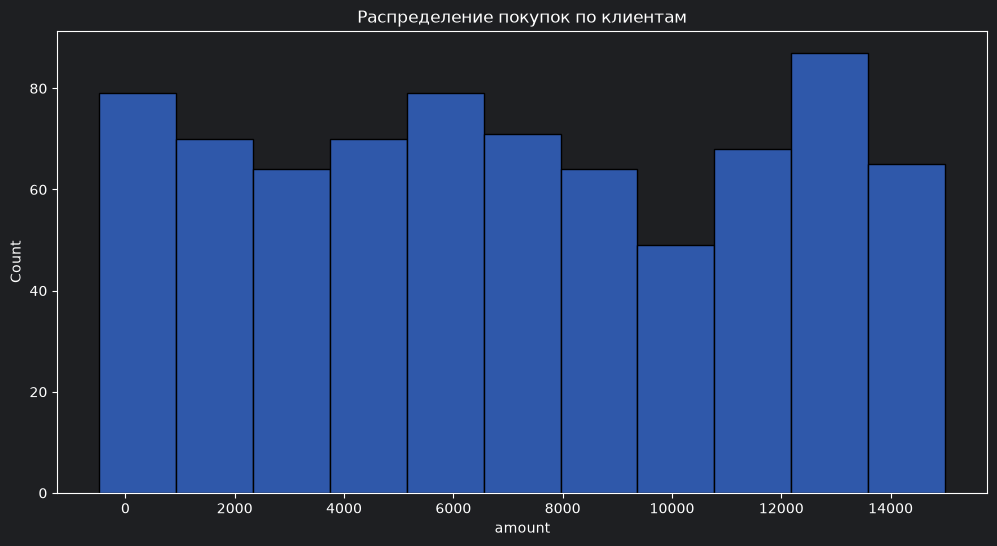

In [4]:
unique_users = df_january['client_uuid'].nunique()
print(f'Количество уникальных клиентов: {unique_users}')

plt.figure(figsize = (12,6))
sns.histplot(data=df_january,x='amount')
plt.title('Распределение покупок по клиентам')
plt.show()

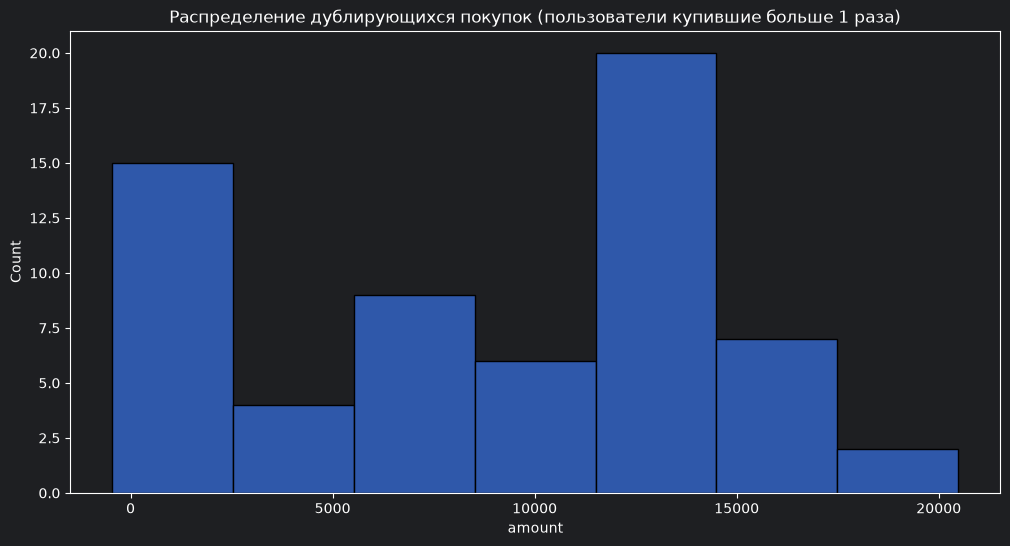

In [5]:
df_duplicates = df_january[df_january['client_uuid'].duplicated()]
df_duplicates = df_duplicates.groupby('client_uuid')['amount'].sum().reset_index()

plt.figure(figsize = (12,6))
sns.histplot(data=df_duplicates,x='amount')
plt.title('Распределение дублирующихся покупок (пользователи купившие больше 1 раза)')
plt.show()

### Итоговый вывод по блоку исследования аномалий:
1. Природа январского пика: Наша гипотеза о техническом сбое или влиянии единичных крупных покупателей ("китов") не подтвердилась. Отношение общего числа покупок к числу уникальных клиентов равно (1.1) (789 транзакций на 718 человек). Максимальный чек находится в пределах нормы. Пик вызван реальным, одновременным наплывом множества уникальных клиентов, совершивших по одной стандартной покупке в период сезонных распродаж.
2. Структура продаж и маркер синтетичности: Общее распределение чеков носит строго равномерный характер — во всех ценовых категориях от 0 до 15 000 рублей совершается стабильно по 50–85 покупок. Это является прямым техническим маркером того, что исходные данные имеют синтетическое (программно сгенерированное) происхождение, что важно зафиксировать перед этапом проектирования DWH.
3. Поведение повторных покупателей: Анализ суммарных затрат клиентов с дублирующими покупками показал, что они не являются случайными покупателями с мелкими заказами. Напротив, наблюдается выраженная концентрация группы клиентов в диапазоне 12 000 — 15 000 рублей суммарных затрат за месяц. Это подтверждает гипотезу о высокой коммерческой эффективности январских маркетинговых кампаний.

# Анализ объемов базовых когорт на Month 0
Описание шага:

Цель этапа — проверить статистическую надежность и репрезентативность формируемых когорт. Нам необходимо оценить объемы входящего потока уникальных клиентов (count) в месяц их первой покупки (month_life = 0).

Это позволит исключить влияние статистического шума (маленьких выборок) на финансовые и продуктовые метрики, а также зафиксировать реальную динамику масштабирования пользовательской базы спортивной платформы.

In [6]:
count_users_cohort = """
with ffirst_purchase as (
-- Формируем таблицу с первой покупкой каждого клиента
	select
		client_uuid,
		min(date_trunc('month', trans_date::date)::date) as cohort_month
	from raw_transactions
group by client_uuid
),
-- Собираем жизненный цикл (все покупки клиентов)
client_lifecycle as (
	select
		fp.cohort_month,
		rt.client_uuid,
		rt.trans_date :: date as trans_date,
		nullif(amount,'error'):: numeric as amount,
		(extract(year from rt.trans_date :: date) * 12 + extract(month from rt.trans_date :: date)) -
		(extract(year from fp.cohort_month) * 12 + extract(month from fp.cohort_month)) as month_life
	from raw_transactions rt
	inner join ffirst_purchase fp on fp.client_uuid  = rt.client_uuid
)
select
	cohort_month,
	count(distinct(client_uuid)) as count
from client_lifecycle
group by cohort_month
order by cohort_month asc
"""
count_users_cohort = pd.read_sql(count_users_cohort, engine,parse_dates=['trans_date'])
count_users_cohort

,cohort_month,count
0,2025-01-01,16
1,2025-02-01,44
2,2025-03-01,89
3,2025-04-01,105
4,2025-05-01,151
5,2025-06-01,169
6,2025-07-01,212
7,2025-08-01,244
8,2025-09-01,282
9,2025-10-01,321


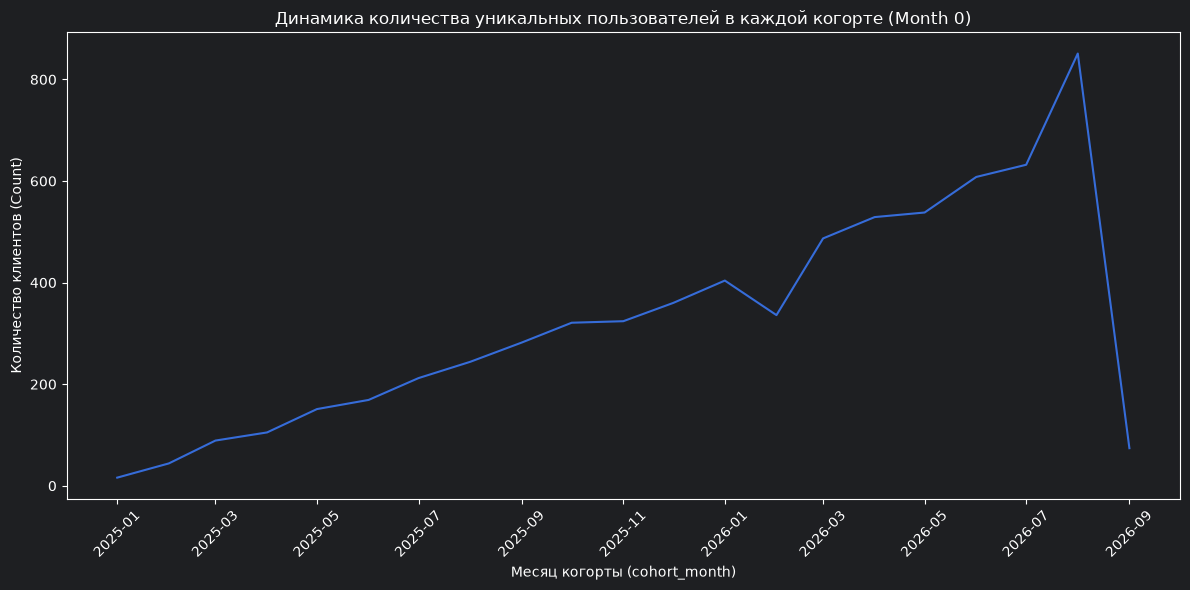

In [8]:
plt.figure(figsize = (12,6))
sns.lineplot(data=count_users_cohort,x='cohort_month',y='count')
plt.title('Динамика количества уникальных пользователей в каждой когорте (Month 0)')
plt.xlabel('Месяц когорты (cohort_month)')
plt.ylabel('Количество клиентов (Count)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Итоговый вывод по блоку анализа объемов:
1. Статистическая надежность трендов: Проверка полностью опровергла гипотезу о случайном характере высокого удержания в 2026 году. Бизнес демонстрирует стабильный кратный рост. Если в начале 2025 года когорты носили характер пилотных групп (январь — 16 человек, февраль — 44), то к середине 2026 года объем входящего потока вырос до 500–600 уникальных платящих пользователей в месяц. Метрики Retention и LTV для 2026 года абсолютно репрезентативны.
2. Локализация маркетингового пика: Обнаружен аномально высокий приток новых клиентов в августе 2026 года (851 человек). Именно этот рекордный объем новой аудитории сформировал мощную вертикальную полосу повышенной монетизации на тепловой карте LTV.
3. Технический обрыв в сентябре 2026 года: Резкое падение графика в финальной точке (сентябрь 2026 — 74 человека) обусловлено техническим фактором: отчетный месяц только начался, и данные по новым покупателям за текущий период еще не успели накопиться в базе данных.